# Titanic Survival Prediction: Data Preprocessing and Feature Engineering

## Objective

The objective of this project is to perform comprehensive data preprocessing and feature engineering on the Titanic dataset to improve the performance of machine learning models for predicting passenger survival.

The project focuses on transforming raw, real-world data into a structured format suitable for machine learning and evaluating how these transformations impact model performance.

Multiple machine learning models are applied to compare results and understand the effectiveness of the overall data preparation pipeline.

## Step 1: Setup and Data Loading

In this step, the Titanic dataset is loaded and initial inspection is performed to understand the structure and available features.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

### Libraries Used

- **Pandas** → Data manipulation
- **NumPy** → Numerical operations
- **Matplotlib & Seaborn** → Data visualization

In [3]:
# Load dataset
df = pd.read_csv('data/titanic.csv')

In [4]:
# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Initial Observations

- Dataset successfully loaded with passenger-level information
- Contains features such as passenger class, age, gender, fare, and embarkation port
- The target variable is **Survived**, indicating whether a passenger survived (1) or not (0)

## Step 2: Data Understanding

This step focuses on exploring the dataset to identify data types, missing values, and overall structure before preprocessing.

### Analysis Approach

- Examine dataset shape and column names
- Identify data types (numerical vs categorical)
- Detect missing values across features
- Understand feature meanings and relevance to survival prediction

In [5]:
# Check shape of dataset
df.shape

(891, 12)

### Dataset Shape

This shows the number of rows and columns in the dataset.

In [6]:
# Display column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Feature Description

The dataset contains information about passengers such as:
- Survival status (target variable)
- Passenger class
- Name
- Gender
- Age
- Family details
- Ticket fare
- Port of embarkation

In [7]:
# Get dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Data Types and Missing Values

This gives information about:
- Data types (numerical/categorical)
- Non-null values
- Missing data presence

In [8]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Missing Value Analysis

- Age column contains missing values → will require imputation
- Cabin has a large number of missing values → may be dropped
- Embarked has very few missing values → can be filled with mode

In [9]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Key Observations

- Dataset contains 891 entries and 12 features
- Both numerical and categorical data are present
- Missing values exist in Age, Cabin, and Embarked
- Cabin has 687 missing values - making it unreliable, while Age has 177 and Embarked has 2 missing values respectively
- Feature engineering will be useful for improving model performance

## Step 3: Data Cleaning

In this step, missing values are handled and irrelevant features are removed to improve data quality.

In [10]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Cleaning Strategy

- Fill missing values in **Age** using median to handle skewness and outliers
- Fill missing values in **Embarked** using mode (most frequent value)
- Drop **Cabin** due to excessive missing values
- Handle missing values in **Fare** using median to avoid data loss

In [11]:
# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column due to too many missing values
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# Drop rows where Fare is missing
df.dropna(subset=['Fare'], inplace=True)

In [12]:
# Convert to categorical types
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')

In [13]:
# Check missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Observations After Cleaning

- Missing values in Age and Embarked successfully handled
- Cabin column removed due to high percentage of missing data
- Fare column cleaned without dropping rows
- No missing values remain
- Dataset is now consistent and ready for feature engineering

## Step 4: Feature Engineering

New features are created from existing data to capture hidden patterns that may improve prediction performance.

### Feature Engineering Strategy

- Create **FamilySize** using SibSp and Parch to capture group size
- Create **IsAlone** to identify passengers traveling alone
- Extract **Title** from passenger names to capture social and demographic information
- Simplify rare titles into broader categories for better generalization

In [14]:
# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [15]:
# Create IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [16]:
# Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)

# Simplify rare titles
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [17]:
# Check survival rate by Title
df.groupby('Title')['Survived'].agg(lambda x: x.astype(int).mean())

Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64

### Observations from Feature Engineering

- FamilySize provides insight into whether passengers traveled in groups
- IsAlone helps distinguish solo travelers from families
- Title reveals important information such as gender, age group, and social status
- Survival rates vary across titles (e.g., higher for Mrs and Miss, lower for Mr)

## Step 5: Encoding Categorical Features

Categorical variables are converted into numerical format so they can be used in machine learning models.

### Encoding Strategy

- Encode **Sex** using binary mapping (male=0, female=1)
- Apply one-hot encoding to **Embarked** and **Title**
- Use drop_first=True to avoid multicollinearity

This ensures that categorical data is properly represented for machine learning models.

In [18]:
# Encode Sex column
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [19]:
# One-hot encode Embarked and Title
df = pd.get_dummies(df, columns=['Embarked','Title'], drop_first=True)

In [20]:
# Check updated columns
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2,0,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,2,0,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,1,1,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,2,0,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,1,1,False,True,False,True,False,False


### Observations After Encoding

- Sex successfully converted into binary numerical format
- Embarked feature transformed into binary columns (Embarked_Q, Embarked_S)
- Title feature expanded into multiple binary columns (e.g., Title_Mr, Title_Miss, etc.)
- Dataset is now fully numerical and suitable for machine learning

## Step 6: Feature Selection

Relevant features are selected based on correlation analysis and domain knowledge to improve model performance.

### Feature Selection Strategy

- Analyze correlation between features and the target variable (Survived)
- Identify features with strong predictive power
- Remove irrelevant or redundant features
- Select a balanced set of original and engineered features

In [21]:
# Convert Survived column back to numeric
df['Survived'] = df['Survived'].astype(int)

# Compute correlation matrix (numeric only)
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Display correlation with target variable
correlation_matrix['Survived'].sort_values(ascending=False)

Survived       1.000000
Sex            0.543351
Fare           0.257307
Parch          0.081629
FamilySize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
IsAlone       -0.203367
Name: Survived, dtype: float64

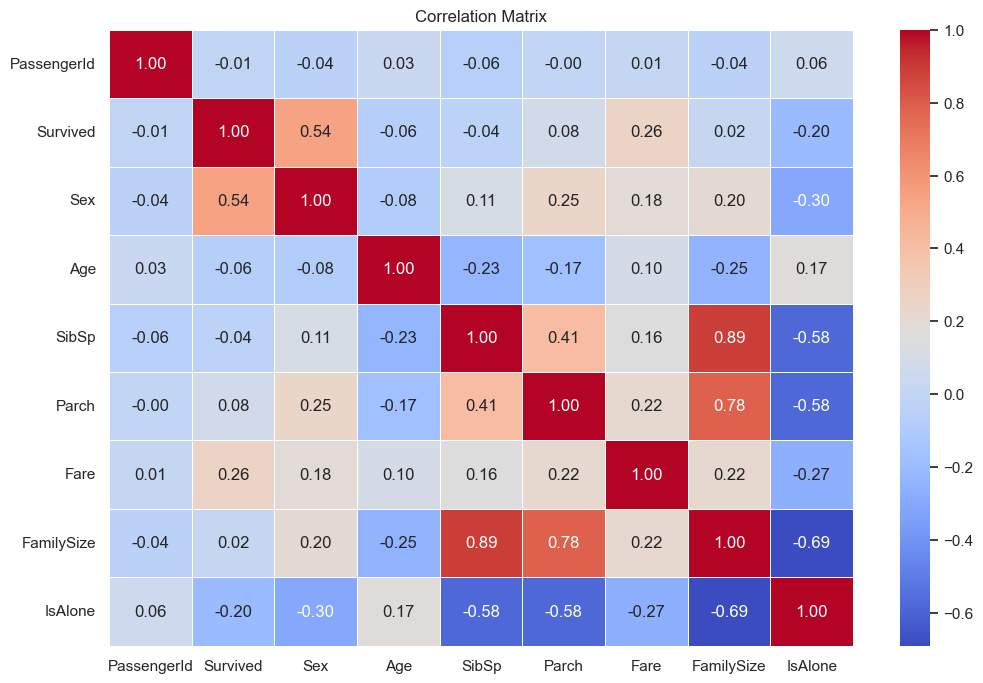

In [22]:
# Plot correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title("Correlation Matrix")
plt.show()

### Observations from Correlation Analysis

- **Sex** shows a strong positive correlation with survival (~0.54), indicating that female passengers had significantly higher survival rates
- **Fare** has a moderate positive correlation with survival (~0.26), suggesting that passengers who paid higher fares were more likely to survive
- **IsAlone** shows a negative correlation (~ -0.20), indicating that passengers traveling alone had lower survival chances
- **Parch** has a slight positive correlation (~0.08), suggesting that passengers traveling with family members had a marginally higher chance of survival
- **Age** shows a weak negative correlation (~ -0.06), indicating a slight tendency for younger passengers to survive more
- **FamilySize** shows very weak correlation (~0.02), suggesting limited direct impact on survival

- Strong correlations exist among engineered features:
  - **FamilySize** is highly correlated with **SibSp (~0.89)** and **Parch (~0.78)**, as expected since it is derived from them
  - **IsAlone** is strongly negatively correlated with **FamilySize (~ -0.69)**, reflecting that passengers with larger families are not alone

- Overall, **Sex and Fare appear to be the most influential features** for predicting survival in this dataset

In [23]:
# Select relevant features
features = [
    'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

X = df[features]
y = df['Survived']

In [24]:
# Check selected features
X.head()

,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,0,22.0,7.2500,2,0,False,True,False,True,False,False
1,1,1,38.0,71.2833,2,0,False,False,False,False,True,False
2,3,1,26.0,7.9250,1,1,False,True,True,False,False,False
3,1,1,35.0,53.1000,2,0,False,True,False,False,True,False
4,3,0,35.0,8.0500,1,1,False,True,False,True,False,False


## Final Summary

The dataset has been successfully prepared for machine learning by:

- Cleaning missing values
- Engineering meaningful features
- Encoding categorical variables
- Selecting relevant features

The data is now ready for model building and evaluation.

## Step 7: Model Building and Evaluation

In this step, multiple machine learning models are trained on the processed Titanic dataset to predict passenger survival. The performance of these models is evaluated and compared to understand the effectiveness of feature engineering and model selection.

### Modeling Approach

- The dataset is split into training (80%) and testing (20%) sets
- Logistic Regression is used as a baseline model for binary classification
- Random Forest and XGBoost are used as advanced models to capture non-linear relationships
- Models are evaluated using accuracy, classification report, and confusion matrix
- Performance comparison is visualized using a bar chart

In [25]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [26]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
# Predictions
y_pred_lr = lr.predict(X_test)

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Predictions
y_pred_rf = rf.predict(X_test)

In [37]:
from xgboost import XGBClassifier

X = X.astype(float)

# Re-split data into training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Model
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
y_pred_xgb = xgb.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("=== Model Accuracy Comparison ===\n")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Random Forest Accuracy      : {rf_acc:.4f}")
print(f"XGBoost Accuracy            : {xgb_acc:.4f}")

# Reports
print("\n=== Logistic Regression Report ===\n")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest Report ===\n")
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost Report ===\n")
print(classification_report(y_test, y_pred_xgb))

=== Model Accuracy Comparison ===

Logistic Regression Accuracy: 0.7989
Random Forest Accuracy      : 0.8324
XGBoost Accuracy            : 0.8324

=== Logistic Regression Report ===

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


=== Random Forest Report ===

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179


=== XGBoost Report ===

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       10

In [40]:
comparison = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "XGBoost"], "Accuracy": [lr_acc, rf_acc, xgb_acc]})

comparison

,Model,Accuracy
0,Logistic Regression,0.798883
1,Random Forest,0.832402
2,XGBoost,0.832402


<Figure size 800x500 with 0 Axes>

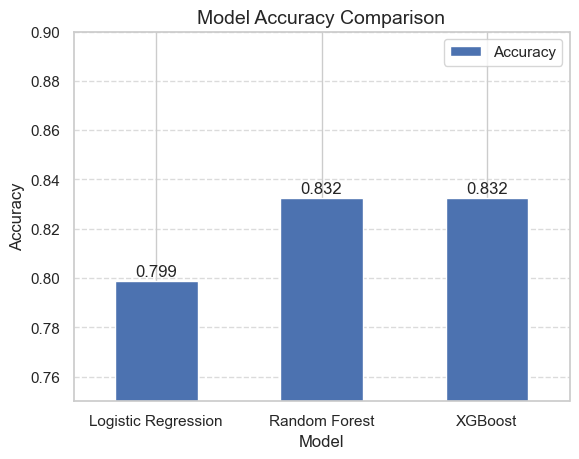

In [41]:
plt.figure(figsize=(8,5))

comparison.set_index("Model").plot(kind="bar")

plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0.75, 0.90)

for index, value in enumerate(comparison["Accuracy"]):
    plt.text(index, value + 0.002, f"{value:.3f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Visualization Insight: Model Accuracy Comparison

The bar chart provides a visual comparison of model performance across Logistic Regression, Random Forest, and XGBoost:

- Logistic Regression achieved an accuracy of approximately **0.799**, while both Random Forest and XGBoost achieved higher and nearly identical accuracies of approximately **0.832**
- The significant improvement from Logistic Regression to tree-based models indicates the presence of non-linear patterns in the dataset that are better captured by ensemble methods
- Random Forest and XGBoost perform equally well in this case, suggesting that both models are effective for this problem
- The moderate performance gap (~3.3%) highlights the advantage of ensemble techniques while also indicating that simpler models still perform reasonably well

The visual comparison aligns with the numerical evaluation and demonstrates the impact of feature engineering in improving model performance.

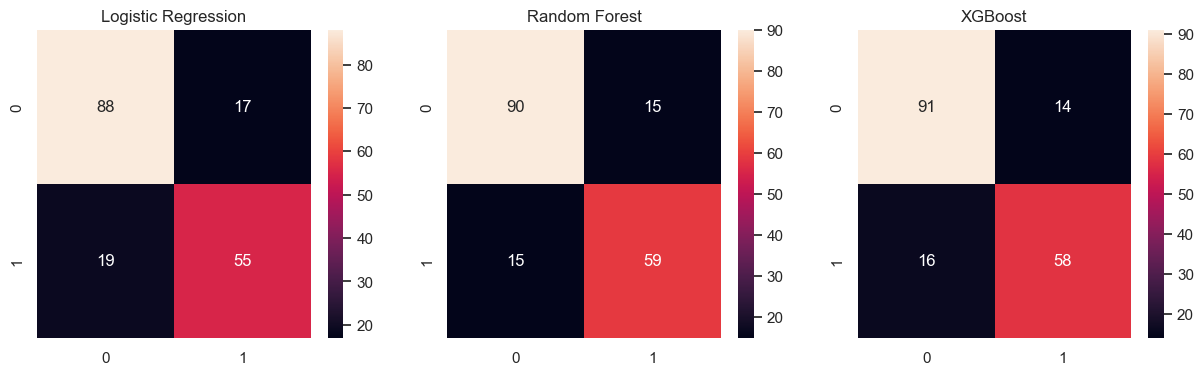

In [42]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression")

plt.subplot(1,3,2)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest")

plt.subplot(1,3,3)
sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("XGBoost")

plt.show()

## Confusion Matrix Analysis

The confusion matrices provide detailed insight into the classification performance of all models:

- True Positives (TP): correctly predicted survivors  
- True Negatives (TN): correctly predicted non-survivors  
- False Positives (FP): non-survivors incorrectly predicted as survivors  
- False Negatives (FN): survivors incorrectly predicted as non-survivors  

- Logistic Regression shows relatively higher misclassification, with **19 false negatives** and **17 false positives**, indicating difficulty in correctly identifying both survivors and non-survivors
- Random Forest improves performance by reducing errors to **15 false positives** and **15 false negatives**, achieving a better balance between classes
- XGBoost performs similarly to Random Forest, with **14 false positives** and **16 false negatives**, showing a comparable level of accuracy and consistency

- All models correctly identify a high number of non-survivors (TN), but tree-based models (Random Forest and XGBoost) show improved classification of survivors compared to Logistic Regression

Overall, Random Forest and XGBoost outperform Logistic Regression by reducing misclassification and better capturing complex patterns in the data, with both models showing very similar performance.

## Model Performance Observations

- Logistic Regression achieved an accuracy of approximately **79.89%**, serving as a strong baseline model for survival prediction
- Random Forest and XGBoost both achieved higher accuracies of approximately **83.24%**, indicating improved performance over the baseline

- The performance improvement from Logistic Regression to tree-based models suggests the presence of non-linear relationships within the dataset that are better captured by ensemble methods
- The similar performance of Random Forest and XGBoost indicates that increasing model complexity beyond a certain point does not significantly improve results for this dataset

- Feature engineering techniques, such as creating **FamilySize**, **IsAlone**, and extracting **Title**, contributed positively to model performance by introducing meaningful patterns
- Key features like **Sex** and **Fare** played a significant role in prediction, as indicated by earlier correlation analysis

Overall, the models demonstrate that well-engineered features combined with appropriate model selection can achieve strong predictive performance on structured datasets like Titanic.

## Final Conclusion

- The Titanic dataset was successfully cleaned and preprocessed by handling missing values, removing irrelevant features, and ensuring all variables were suitable for machine learning models  
- Feature engineering introduced meaningful variables such as **FamilySize**, **IsAlone**, and **Title**, enhancing the dataset’s ability to capture passenger behavior and social patterns  
- Categorical features were effectively encoded into numerical form, making the data compatible with machine learning algorithms  

- Logistic Regression provided a strong baseline performance, while **Random Forest and XGBoost achieved higher and nearly identical accuracies (~83.24%)**, demonstrating the effectiveness of ensemble methods in capturing non-linear relationships  
- The comparable performance of Random Forest and XGBoost indicates that increasing model complexity beyond a certain point does not significantly improve results for this dataset  

- Model evaluation using accuracy, classification reports, and confusion matrices provided a comprehensive understanding of performance, highlighting the strengths of tree-based models in reducing misclassification  

Overall, this project demonstrates a complete end-to-end machine learning pipeline—from data preprocessing and feature engineering to model building, evaluation, and comparison—emphasizing the importance of data preparation and thoughtful model selection in achieving strong predictive performance.